## Targets of this notebook
- find the anomalous behaviour within the dataset
- provide insights on data from ML perspecive (outlier-wise)
- serve as a first step towards anomaly detesction using Deep learning

In [39]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from src.plotting_styles import apply_global_style
from src.load_sam_data import load_dataset

# FJ

In [40]:
dataset = load_dataset("FJ")

data\FJ\FI01X1\FI01X1_ch


In [41]:
from src.autoencoders import minmax_scale_per_sample
dataset = minmax_scale_per_sample(dataset)

In [42]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

neigh = NearestNeighbors(n_neighbors=len(dataset))
neigh.fit(dataset)

neighborhood = []
for d in dataset:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

In [43]:
len(set(deviations))

613

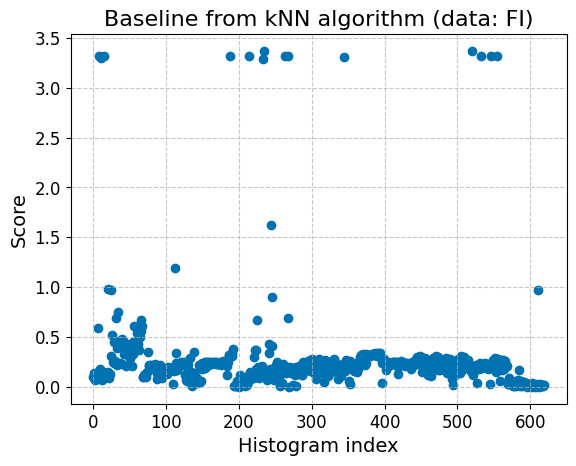

In [44]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: FI)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [45]:
possible_outlier =  [deviations.index(dev) for dev in deviations if dev > 1.5 and dev < 2]
possible_outlier

[244]

## Points that could be outliers

In [75]:
outliers_knn = np.where(np.array(deviations) > 2.0)[0].tolist()
print(outliers_knn)
len(outliers_knn)

[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]


14

In [76]:
for i in outliers_knn:
    print(i, deviations[i])

8 3.3129048385862907
11 3.2947734888458013
15 3.3129048385862907
188 3.3129048385862907
214 3.3129048385862907
233 3.286210358328642
234 3.365502678956962
263 3.3129048385862907
268 3.3129048385862907
344 3.310506111376954
520 3.3678831294594804
533 3.3129048385862907
546 3.3129048385862907
555 3.321789143924997


In [47]:
knn_weird = [deviations.index(dev) for dev in deviations if dev > 1]
knn_weird = [i for i in knn_weird if i > 500]
knn_weird

[520, 555]

In [48]:
deviations[555]

np.float64(3.321789143924997)

In [49]:
table = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 1.5}
table

{8: np.float64(3.3129),
 11: np.float64(3.2948),
 233: np.float64(3.2862),
 234: np.float64(3.3655),
 244: np.float64(1.6264),
 344: np.float64(3.3105),
 520: np.float64(3.3679),
 555: np.float64(3.3218)}

<BarContainer object of 96 artists>

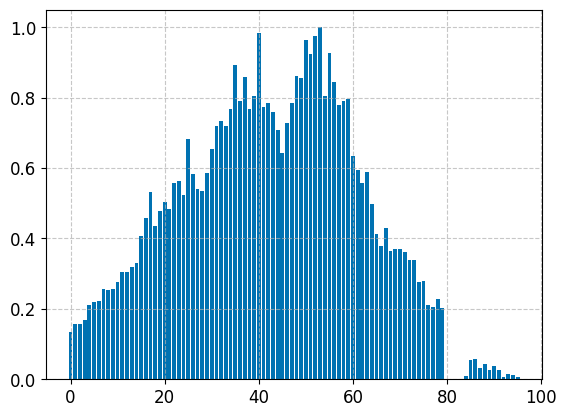

In [50]:
apply_global_style()
plt.bar(range(len(dataset[361])), dataset[361])

## Is point 113 outlier?

<BarContainer object of 96 artists>

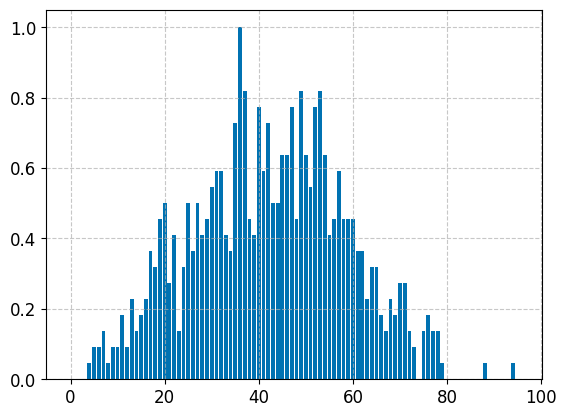

In [51]:
apply_global_style()

plt.bar(range(len(dataset[613])), dataset[113])

## Let's try OCSVM

In [52]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(dataset)
svm.fit_predict(dataset)
prediction = svm.predict(dataset)
out_measure = svm.score_samples(dataset)

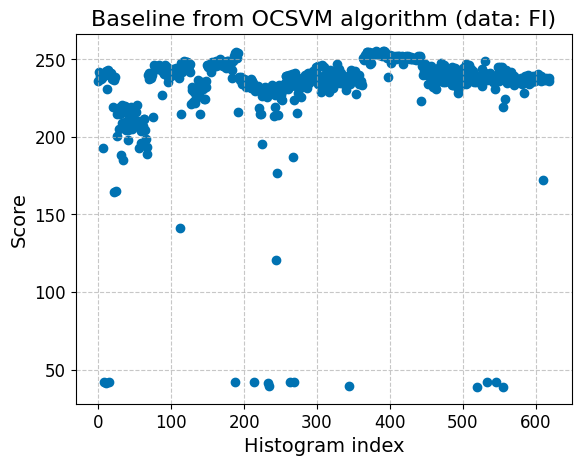

In [53]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: FI)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [54]:
len(outliers_knn)

14

In [55]:
outliers_svm = np.where(out_measure < 50)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm.tolist()}")
print(f"Outliers detected by knn {outliers_knn.tolist()}")
print(f'Same number of outliers: {len(outliers_knn) == len(outliers_svm)}')

(SVM) Highest outlier score assigned to:  [520]
(KNN) Highest outlier score assigned to:  520
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
Outliers detected by svm [8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]
Outliers detected by knn [8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]
Same number of outliers: True


In [56]:
sorted(out_measure[-10:])

[np.float64(172.20706424725495),
 np.float64(235.93636853935007),
 np.float64(236.53717031232426),
 np.float64(236.99681724880054),
 np.float64(237.22801480158643),
 np.float64(237.24514116221613),
 np.float64(237.3665288265288),
 np.float64(237.6634894658379),
 np.float64(237.80032606669835),
 np.float64(238.10602532237587)]

In [ ]:
table_svm = {idx : round(score, 4) for idx, score in enumerate(out_measure) if score < 50}
table_svm

{8: np.float64(41.6512),
 11: np.float64(41.1477),
 15: np.float64(41.6512),
 188: np.float64(41.6512),
 214: np.float64(41.6512),
 233: np.float64(41.4012),
 234: np.float64(39.1337),
 263: np.float64(41.6512),
 268: np.float64(41.6512),
 344: np.float64(39.6349),
 520: np.float64(38.777),
 533: np.float64(41.6512),
 546: np.float64(41.6512),
 555: np.float64(38.9137)}

In [59]:
len(table_svm)

14

In [63]:
np.where(np.array(deviations) > 3)

(array([  8,  11,  15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546,
        555]),)

In [64]:
sorted(deviations)[-14:]

[np.float64(3.286210358328642),
 np.float64(3.2947734888458013),
 np.float64(3.310506111376954),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.3129048385862907),
 np.float64(3.321789143924997),
 np.float64(3.365502678956962),
 np.float64(3.3678831294594804)]

In [70]:
len(deviations)

620

In [73]:
table_knn = [(deviations.index(dev), round(dev, 4)) for dev in deviations if dev > 3]
table_knn

[(8, np.float64(3.3129)),
 (11, np.float64(3.2948)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (233, np.float64(3.2862)),
 (234, np.float64(3.3655)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (344, np.float64(3.3105)),
 (520, np.float64(3.3679)),
 (8, np.float64(3.3129)),
 (8, np.float64(3.3129)),
 (555, np.float64(3.3218))]

In [69]:
table_knn = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 3}
table_knn

{8: np.float64(3.3129),
 11: np.float64(3.2948),
 233: np.float64(3.2862),
 234: np.float64(3.3655),
 344: np.float64(3.3105),
 520: np.float64(3.3679),
 555: np.float64(3.3218)}

In [68]:
table_knn = {deviations.index(dev): round(dev, 4) for dev in deviations if dev > 3}
table_knn

{8: np.float64(3.3129),
 11: np.float64(3.2948),
 233: np.float64(3.2862),
 234: np.float64(3.3655),
 344: np.float64(3.3105),
 520: np.float64(3.3679),
 555: np.float64(3.3218)}

In [60]:
len(table_knn)

7

# PA

In [22]:
pa_data = load_dataset("PA")

data\MWPC\PA01U1\PA01U1_ch


<BarContainer object of 768 artists>

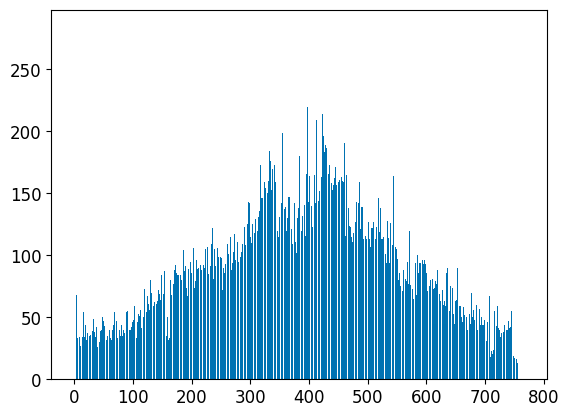

In [23]:
plt.bar(range(len(pa_data[0])), pa_data[0])

In [24]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
pa_data = scaler.fit_transform(pa_data)

neigh = NearestNeighbors(n_neighbors=len(pa_data))
neigh.fit(pa_data)

neighborhood = []
for d in pa_data:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

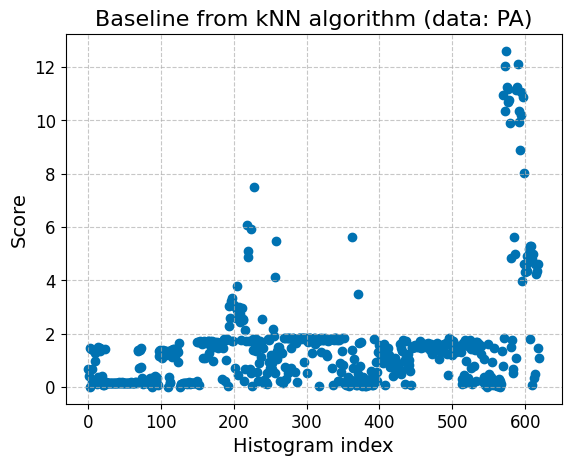

In [25]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [26]:
outliers_knn = [deviations.index(dev) for dev in deviations if dev > 8]
len(outliers_knn), outliers_knn

(19,
 [570,
  572,
  573,
  574,
  575,
  576,
  577,
  578,
  579,
  588,
  589,
  590,
  591,
  592,
  593,
  594,
  595,
  597,
  598])

In [27]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(pa_data)
svm.fit_predict(pa_data)
prediction = svm.predict(pa_data)
out_measure = svm.score_samples(pa_data)

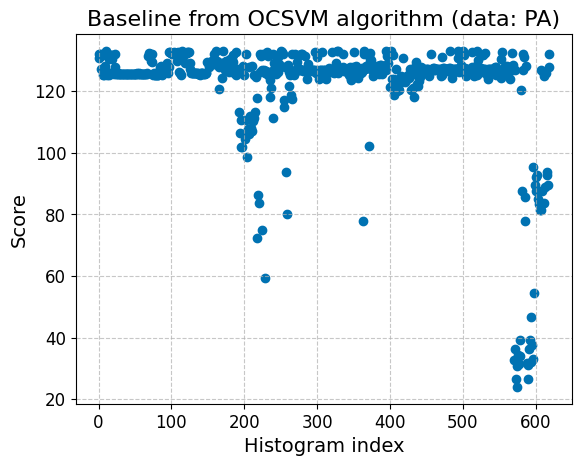

In [28]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [29]:
outliers_svm = np.where(out_measure < 60)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [574]
(KNN) Highest outlier score assigned to:  574
False
Outliers detected by svm [228 570 572 573 574 575 576 577 578 579 588 589 590 591 592 593 594 595
 597 598]
Outliers detected by knn [570, 572, 573, 574, 575, 576, 577, 578, 579, 588, 589, 590, 591, 592, 593, 594, 595, 597, 598]


Zde vidime ze pokud vezmeme hranici 60 ktera se zda byt vhodna dostavame v SVM pristupu o jeden outlier vice dataset je mnohem vice scattered a narozdil od predesleho FJ datasetu je v nem mnohem vic nejasnych bodu, ikdyz se na prvni pohled metody shodujji v skorovani vidime ze OCSVM je dulezite na zaklade tehto vysledku byt ostrazity hlavne v dobech ktere se nachazi mezi jasnymi outliery a clustrem bodu ktere jsou blizko u sebe.. (neco takoveho napsat idk)

# SI

In [30]:
si_data = load_dataset("SI")

data\SI\SI01U1\SI01U1_ch


<BarContainer object of 1280 artists>

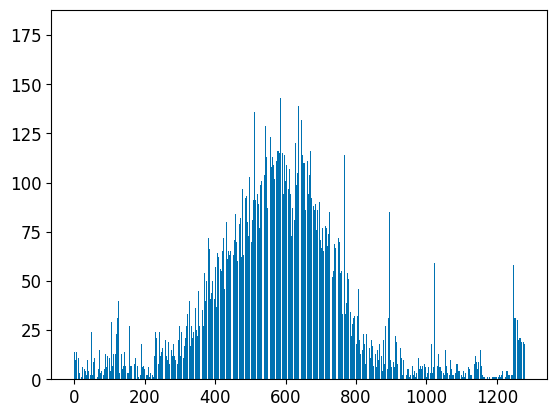

In [31]:
plt.bar(range(len(si_data[0])), si_data[0])

In [32]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
si_data = scaler.fit_transform(si_data)

neigh = NearestNeighbors(n_neighbors=len(si_data))
neigh.fit(si_data)

neighborhood = []
for d in si_data:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

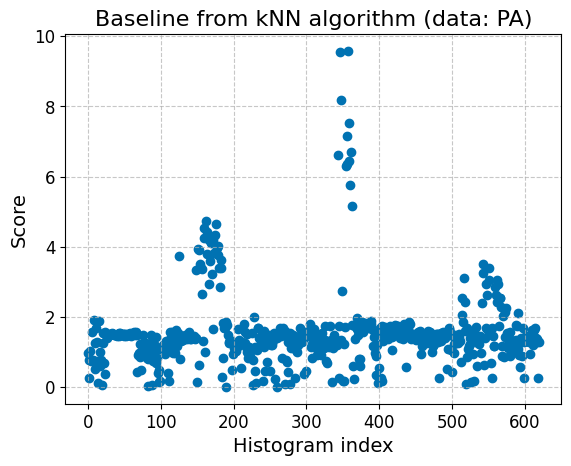

In [33]:
apply_global_style()
plt.title("Baseline from kNN algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(deviations)), deviations)

In [34]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(si_data)
svm.fit_predict(si_data)
prediction = svm.predict(si_data)
out_measure = svm.score_samples(si_data)

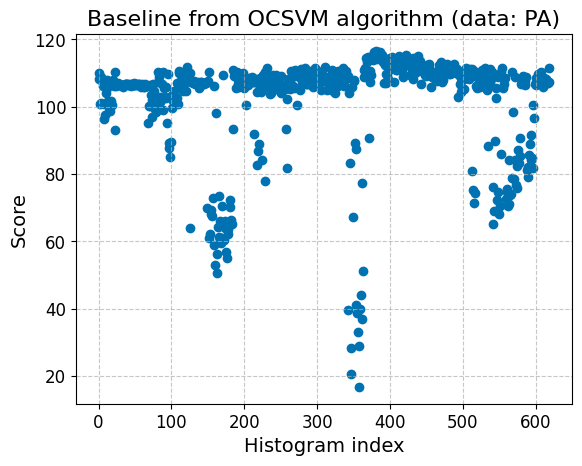

In [35]:
apply_global_style()
plt.title("Baseline from OCSVM algorithm (data: PA)")
plt.xlabel("Histogram index")
plt.ylabel("Score")
plt.scatter(range(len(out_measure)), out_measure)

In [36]:
outliers_svm = np.where(out_measure < 110)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")

(SVM) Highest outlier score assigned to:  [357]
(KNN) Highest outlier score assigned to:  357
False
Outliers detected by svm [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  83  84  85  86  87  89  90  91  92
  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 111
 112 113 114 115 116 117 118 120 122 124 125 127 128 129 130 131 132 133
 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151
 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170
 171 172 173 174 175 176 177 178 179 180 181 182 183 185 186 187 188 189
 191 192 193 194 195 196 197 199 200 201 202 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227